<a href="https://colab.research.google.com/github/SergeiVKalinin/Probabilistic-Unmixing-0/blob/main/notebooks/08_Level_2_Posterior_Correlation_and_Propagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 08 — Level 2: Posterior Correlation, Coupling, and Uncertainty Propagation

Before conditioning on the measured mixtures, the Level 2 functional coefficients are independent standard-normal coordinates. After conditioning, that independence generally disappears.

The likelihood can couple:

- different functional modes of the same endmember;
- different endmembers;
- spectral functions and local concentrations;
- predictions at different measurement locations through the globally shared endmembers.

This notebook reconstructs joint Gaussian/Laplace posterior draws from the current Level 2 engine so that these dependencies can be visualized directly.

**Important:** `pu.fit(data, level=2)` remains the normal public API. The additional code below uses internal Level 2 objects only to expose the joint posterior geometry for teaching and diagnostics.

In [ ]:
!pip install -q --force-reinstall --no-deps git+https://github.com/SergeiVKalinin/Probabilistic-Unmixing-0.git

import numpy as np
import matplotlib.pyplot as plt
import probunmix as pu

print("probunmix version:", pu.__version__)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
probunmix version: 0.1.0


## Fit a compact Level 2 problem

We use a moderate dataset so that the advanced diagnostics run comfortably in Colab.

In [ ]:
data = pu.generate_example(
    n_locations=30,
    n_channels=90,
    n_library=100,
    concentration_uncertainty=[0.03, 0.03, 0.06, 0.08],
    spectral_uncertainty=[1.0, 1.5, 1.0, 2.0],
    seed=42,
)

result2 = pu.fit(
    data,
    level=2,
    n_draws=600,
    seed=202,
    max_nfev=200,
)

print(result2.metrics)
print("Functional ranks:", result2.metadata["ranks"])

{'reconstruction_rmse': 0.010129613011569068, 'mean_concentration_sd': 0.007363894511669929, 'mean_spectral_sd': 0.001958053082064659, 'n_functional_parameters': 45, 'n_total_parameters': 135, 'optimizer_cost': 1360.5238224644138, 'optimizer_nfev': 78, 'concentration_rmse': 0.008159800735834123, 'spectral_rmse': 0.0038055990947031557}
Functional ranks: [12, 12, 9, 12]


## Reconstruct joint posterior draws

`UnmixingResult` intentionally stores compact posterior summaries. For this advanced notebook we reproduce the same MAP + Gauss–Newton Laplace calculation and retain the joint draws.

These draws preserve spectral–spectral, component–component, and concentration–spectral dependencies.

In [ ]:
from scipy.optimize import least_squares

from probunmix.level2 import (
    _build_representations,
    _Level2Problem,
    _gaussian_draws,
    _quadrature_weights,
    _spectrum_from_coefficients,
)

representations, _ = _build_representations(
    data.E,
    data.S_library,
    variance_threshold=0.995,
    min_rank=4,
    max_rank=12,
)

problem = _Level2Problem(
    data,
    representations,
)

x0 = np.zeros(problem.n_parameters)

solution = least_squares(
    problem.residual,
    x0=x0,
    jac=problem.jacobian,
    method="trf",
    max_nfev=200,
    xtol=1e-9,
    ftol=1e-9,
    gtol=1e-9,
)

J = solution.jac
precision = J.T @ J
precision = 0.5 * (precision + precision.T)
covariance_x = np.linalg.pinv(precision)
covariance_x = 0.5 * (covariance_x + covariance_x.T)

rng = np.random.default_rng(202)

x_draws = _gaussian_draws(
    mean=solution.x,
    covariance=covariance_x,
    n_draws=600,
    rng=rng,
)

W_draws = np.empty(
    (len(x_draws), data.n_locations, data.n_components)
)

S_draws = np.empty(
    (len(x_draws), data.n_components, data.n_channels)
)

for d, x in enumerate(x_draws):
    S, W = problem.unpack(x, derivatives=False)
    S_draws[d] = S
    W_draws[d] = W

print("W draws:", W_draws.shape)
print("S draws:", S_draws.shape)

print(
    "Agreement with compact result, S mean RMS:",
    np.sqrt(np.mean((S_draws.mean(axis=0) - result2.S_mean)**2)),
)

W draws: (600, 30, 4)
S draws: (600, 4, 90)
Agreement with compact result, S mean RMS: 1.0880325334188651e-07


## Prior versus posterior covariance within one endmember

We first compare the physical-intensity covariance of one component before and after learning from mixtures.

The prior draws are generated from the retained functional representation, not by perturbing individual spectral channels.

In [ ]:
component = 1  # Component 2

rep = representations[component]
q = _quadrature_weights(data.E)

rng_prior = np.random.default_rng(123)

prior_coefficients = rng_prior.normal(
    size=(1200, rep["rank"])
)

S_prior = np.array([
    _spectrum_from_coefficients(
        rep["mean"],
        rep["basis"],
        a,
        q,
    )
    for a in prior_coefficients
])

S_post = S_draws[:, component, :]

cov_prior = np.cov(S_prior, rowvar=False, ddof=1)
cov_post = np.cov(S_post, rowvar=False, ddof=1)

print("Mean prior pointwise SD:",
      np.sqrt(np.diag(cov_prior)).mean())
print("Mean posterior pointwise SD:",
      np.sqrt(np.diag(cov_post)).mean())

Mean prior pointwise SD: 0.11508296075183608
Mean posterior pointwise SD: 0.0013451582346259035


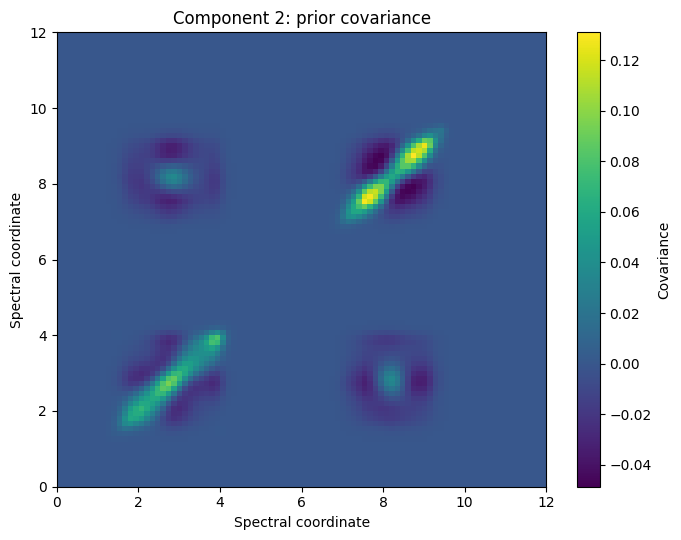

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5.5))

image = ax.imshow(
    cov_prior,
    origin="lower",
    aspect="auto",
    extent=[data.E[0], data.E[-1], data.E[0], data.E[-1]],
)

ax.set_xlabel("Spectral coordinate")
ax.set_ylabel("Spectral coordinate")
ax.set_title(f"Component {component+1}: prior covariance")
fig.colorbar(image, ax=ax, label="Covariance")
fig.tight_layout();

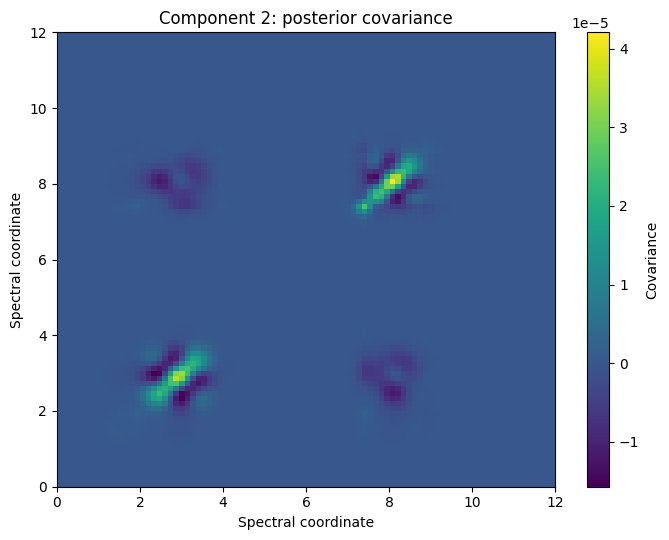

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5.5))

image = ax.imshow(
    cov_post,
    origin="lower",
    aspect="auto",
    extent=[data.E[0], data.E[-1], data.E[0], data.E[-1]],
)

ax.set_xlabel("Spectral coordinate")
ax.set_ylabel("Spectral coordinate")
ax.set_title(f"Component {component+1}: posterior covariance")
fig.colorbar(image, ax=ax, label="Covariance")
fig.tight_layout();

## Correlation can survive strong uncertainty contraction

Posterior covariance can become very small in absolute magnitude while strong positive and negative correlation patterns remain.

Correlation should therefore be interpreted together with pointwise SD.

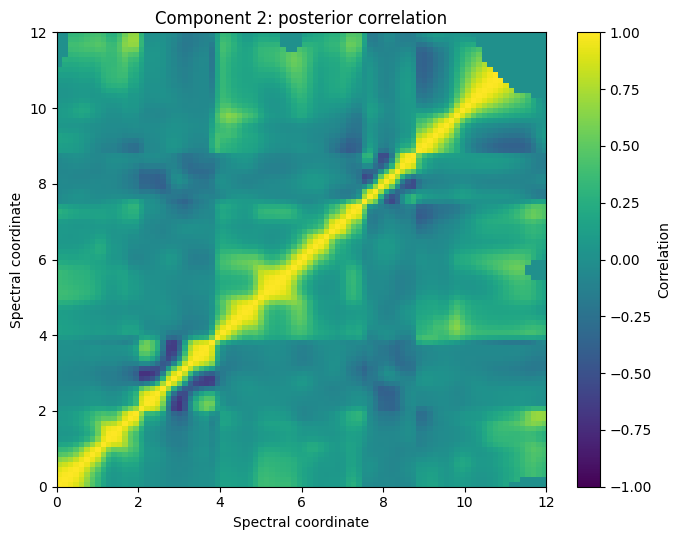

In [ ]:
def covariance_to_correlation(cov):
    sd = np.sqrt(np.maximum(np.diag(cov), 0.0))
    denom = np.outer(sd, sd)
    return np.divide(
        cov,
        denom,
        out=np.zeros_like(cov),
        where=denom > 1e-15,
    )

corr_post = covariance_to_correlation(cov_post)

fig, ax = plt.subplots(figsize=(7, 5.5))

image = ax.imshow(
    corr_post,
    origin="lower",
    aspect="auto",
    vmin=-1,
    vmax=1,
    extent=[data.E[0], data.E[-1], data.E[0], data.E[-1]],
)

ax.set_xlabel("Spectral coordinate")
ax.set_ylabel("Spectral coordinate")
ax.set_title(f"Component {component+1}: posterior correlation")
fig.colorbar(image, ax=ax, label="Correlation")
fig.tight_layout();

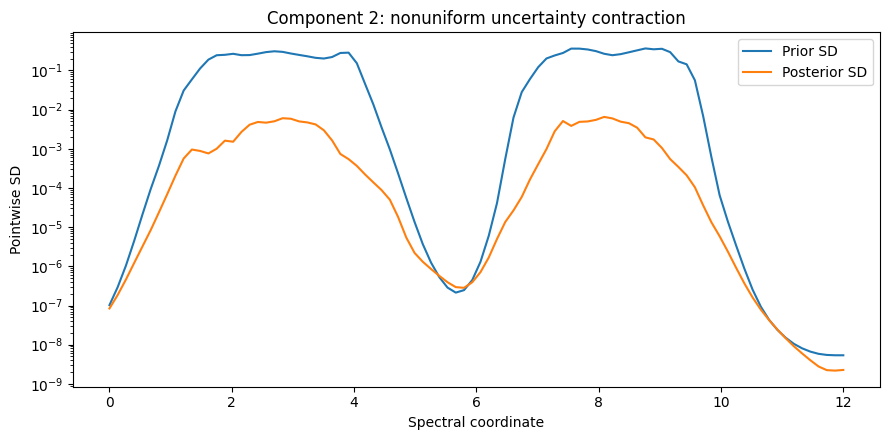

In [ ]:
prior_sd = S_prior.std(axis=0, ddof=1)
post_sd = S_post.std(axis=0, ddof=1)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.semilogy(data.E, np.maximum(prior_sd, 1e-15), label="Prior SD")
ax.semilogy(data.E, np.maximum(post_sd, 1e-15), label="Posterior SD")
ax.set_xlabel("Spectral coordinate")
ax.set_ylabel("Pointwise SD")
ax.set_title(f"Component {component+1}: nonuniform uncertainty contraction")
ax.legend()
fig.tight_layout();

## Cross-component spectral dependence

After conditioning, different endmembers can compensate one another in the mixture. To make this visible, we take one representative high-intensity channel from each recovered endmember and compute the posterior correlation between those four intensities.

Off-diagonal values are evidence of posterior coupling between components.

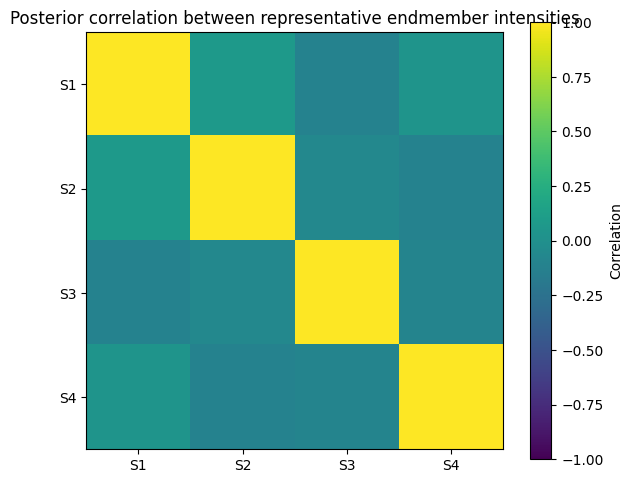

In [ ]:
peak_index = np.argmax(result2.S_mean, axis=1)

peak_intensity_draws = np.column_stack([
    S_draws[:, k, peak_index[k]]
    for k in range(data.n_components)
])

cross_component_corr = np.corrcoef(
    peak_intensity_draws,
    rowvar=False,
)

fig, ax = plt.subplots(figsize=(6, 5))

image = ax.imshow(
    cross_component_corr,
    vmin=-1,
    vmax=1,
)

labels = [f"S{k+1}" for k in range(data.n_components)]
ax.set_xticks(np.arange(data.n_components))
ax.set_xticklabels(labels)
ax.set_yticks(np.arange(data.n_components))
ax.set_yticklabels(labels)
ax.set_title("Posterior correlation between representative endmember intensities")
fig.colorbar(image, ax=ax, label="Correlation")
fig.tight_layout();

## Concentration–spectral coupling

A spectral deformation can sometimes be offset by a change in mixture fraction. The joint posterior should preserve this dependence.

We select a strongly mixed measurement location and construct a correlation matrix between its four fractions and representative intensities of the four global endmembers.

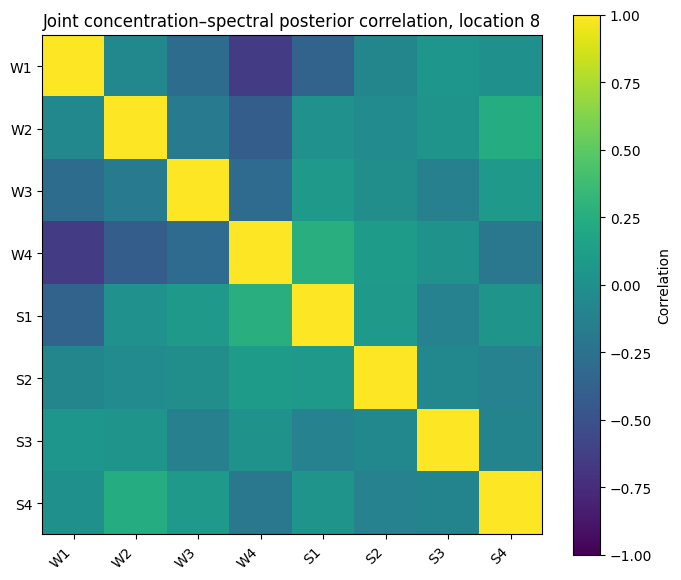

In [ ]:
location = np.argmin(
    np.max(data.W_mean, axis=1)
)

W_local = W_draws[:, location, :]

joint_variables = np.column_stack([
    W_local,
    peak_intensity_draws,
])

joint_corr = np.corrcoef(
    joint_variables,
    rowvar=False,
)

labels = (
    [f"W{k+1}" for k in range(data.n_components)]
    + [f"S{k+1}" for k in range(data.n_components)]
)

fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(
    joint_corr,
    vmin=-1,
    vmax=1,
)

ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels)
ax.set_title(f"Joint concentration–spectral posterior correlation, location {location}")
fig.colorbar(image, ax=ax, label="Correlation")
fig.tight_layout();

## Propagate the joint uncertainty into a mixture prediction

At one location, write

$$w = \bar w + \Delta w,\qquad S = \bar S + \Delta S.$$

The latent mixture contains three fluctuation terms:

- concentration-only: $\Delta w\,\bar S$;
- endmember-only: $\bar w\,\Delta S$;
- interaction: $\Delta w\,\Delta S$.

Their variances do **not** generally add by themselves because the terms are correlated. Signed cross-covariances must also be retained.

Observation noise is intentionally excluded here; we are examining uncertainty in the latent mixture.

In [ ]:
wbar = W_draws[:, location, :].mean(axis=0)
Sbar = S_draws.mean(axis=0)

dw = W_draws[:, location, :] - wbar
dS = S_draws - Sbar

term_W = np.einsum("dk,km->dm", dw, Sbar)
term_S = np.einsum("k,dkm->dm", wbar, dS)
term_interaction = np.einsum("dk,dkm->dm", dw, dS)

# The interaction can have a nonzero mean.
term_interaction_centered = (
    term_interaction - term_interaction.mean(axis=0)
)

def variance(x):
    return np.var(x, axis=0, ddof=1)

def covariance_xy(x, y):
    xc = x - x.mean(axis=0)
    yc = y - y.mean(axis=0)
    return np.sum(xc * yc, axis=0) / (x.shape[0] - 1)

var_W = variance(term_W)
var_S = variance(term_S)
var_I = variance(term_interaction_centered)

cross = 2.0 * (
    covariance_xy(term_W, term_S)
    + covariance_xy(term_W, term_interaction_centered)
    + covariance_xy(term_S, term_interaction_centered)
)

mixture_draws = np.einsum(
    "dk,dkm->dm",
    W_draws[:, location, :],
    S_draws,
)

total_variance = variance(mixture_draws)

reconstructed_variance = (
    var_W + var_S + var_I + cross
)

print(
    "Maximum variance-decomposition residual:",
    np.max(np.abs(total_variance - reconstructed_variance)),
)

Maximum variance-decomposition residual: 6.776263578034403e-20


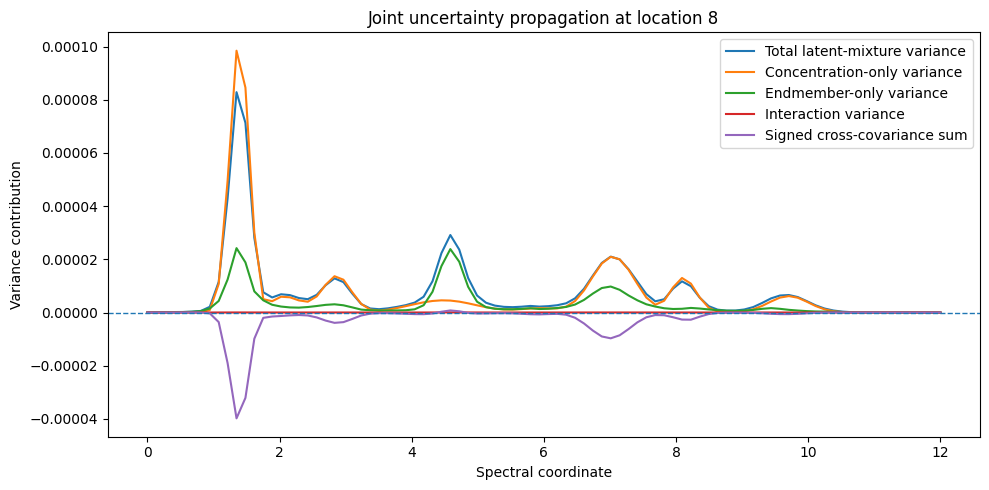

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(data.E, total_variance, label="Total latent-mixture variance")
ax.plot(data.E, var_W, label="Concentration-only variance")
ax.plot(data.E, var_S, label="Endmember-only variance")
ax.plot(data.E, var_I, label="Interaction variance")
ax.plot(data.E, cross, label="Signed cross-covariance sum")

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xlabel("Spectral coordinate")
ax.set_ylabel("Variance contribution")
ax.set_title(f"Joint uncertainty propagation at location {location}")
ax.legend()
fig.tight_layout();

## Takeaway

Level 2 posterior uncertainty is a joint object.

- Covariance links different spectral coordinates.
- Conditioning can correlate different endmembers.
- Concentrations and spectra can become correlated.
- Global spectral uncertainty links predictions across measurement locations.
- Mixture-prediction variance cannot in general be decomposed by adding independent nonnegative concentration and spectral variance curves.

These dependencies are exactly why preserving **joint posterior draws** matters for advanced uncertainty propagation.